##Week 6 - Image Denoising using Autoencoder on MNIST

## Project Description

Image denoising is an important computer vision task that focuses on removing unwanted noise from images while preserving meaningful visual information.

In this project, a Convolutional Autoencoder is developed to learn compressed representations of handwritten digit images from the MNIST dataset. The model is trained using noisy images as input and clean images as target outputs, enabling it to reconstruct denoised versions of corrupted images.

The performance of the model is evaluated using reconstruction loss, Mean Squared Error (MSE), and visual comparison between original, noisy, and reconstructed images.

## Project Description

Image denoising is an important computer vision task that focuses on removing unwanted noise from images while preserving meaningful visual information.

In this project, a Convolutional Autoencoder is developed to learn compressed representations of handwritten digit images from the MNIST dataset. The model is trained using noisy images as input and clean images as target outputs, enabling it to reconstruct denoised versions of corrupted images.

The performance of the model is evaluated using reconstruction loss, Mean Squared Error (MSE), and visual comparison between original, noisy, and reconstructed images.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

In [2]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

print("Train Shape:", x_train.shape)
print("Test Shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train Shape: (60000, 28, 28)
Test Shape: (10000, 28, 28)


## Visualizing MNIST Digits

Before adding noise, we inspect a few sample handwritten digits from the MNIST dataset.

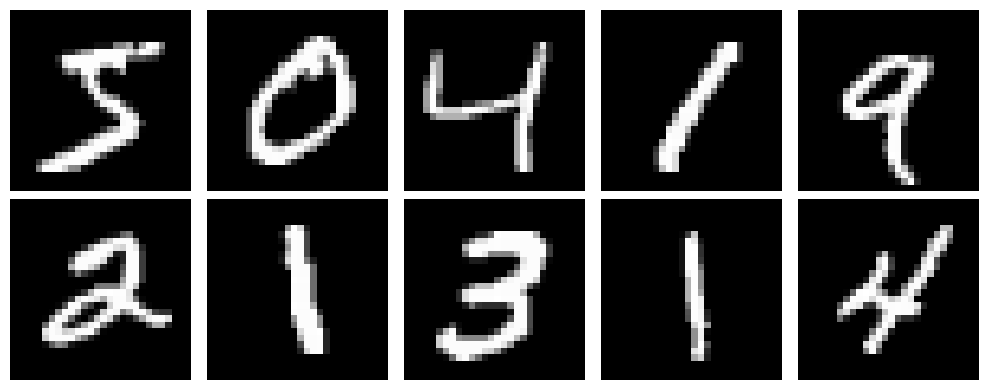

In [3]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Data Preprocessing

Pixel values are normalized from the range [0,255] to [0,1] to improve training stability.

The images are reshaped to include a channel dimension required for convolutional layers.

In [4]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.reshape(x_train, (-1,28,28,1))
x_test = np.reshape(x_test, (-1,28,28,1))

print("Train Shape:", x_train.shape)
print("Test Shape:", x_test.shape)

Train Shape: (60000, 28, 28, 1)
Test Shape: (10000, 28, 28, 1)


## Noise Generation

Artificial Gaussian noise is added to the images to simulate image corruption.

The autoencoder will learn to reconstruct clean images from these noisy inputs.

In [5]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noisy Train Shape:", x_train_noisy.shape)

Noisy Train Shape: (60000, 28, 28, 1)


## Original vs Noisy Image Comparison

The following visualization compares clean MNIST images with their noisy counterparts.

This helps evaluate the severity of corruption before training the autoencoder.

## Convolutional Autoencoder Architecture

The autoencoder consists of:

### Encoder
- Conv2D
- MaxPooling
- Conv2D
- MaxPooling

The encoder compresses the noisy image into a compact representation.

### Decoder
- Conv2D
- UpSampling
- Conv2D
- UpSampling

The decoder reconstructs a cleaner version of the image from the compressed representation.

In [6]:
input_img = layers.Input(shape=(28,28,1))

# Encoder
x = layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = layers.MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = layers.Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

encoded = layers.MaxPooling2D(
    (2,2),
    padding='same'
)(x)

# Decoder
x = layers.Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(encoded)

x = layers.UpSampling2D(
    (2,2)
)(x)

x = layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = layers.UpSampling2D(
    (2,2)
)(x)

decoded = layers.Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

The autoencoder is trained using noisy images as input and clean images as target outputs.

The objective is to minimize reconstruction loss and learn a denoised representation of the images.


In [7]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.1594 - val_loss: 0.1142
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1112 - val_loss: 0.1064
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1058 - val_loss: 0.1033
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1030 - val_loss: 0.1008
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1010 - val_loss: 0.0996
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0997 - val_loss: 0.0984
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0986 - val_loss: 0.0975
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0979 - val_loss: 0.0968
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0972 - val_loss: 0.0965
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0966 - val_loss: 0.0959


## Training Loss Analysis

The training and validation losses were monitored throughout the learning process to evaluate convergence and reconstruction performance.

A consistent decrease in both losses indicates successful learning and stable generalization.

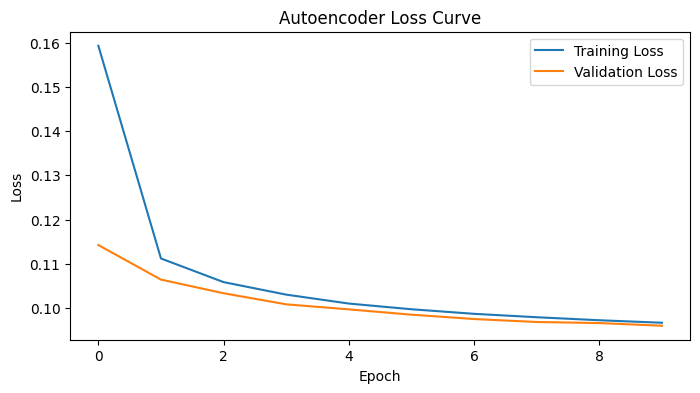

In [8]:
plt.figure(figsize=(8,4))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Autoencoder Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [9]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [12]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    x_test.flatten(),
    decoded_imgs.flatten()
)

print("Reconstruction MSE:", mse)

Reconstruction MSE: 0.011015455238521099


## Quantitative Evaluation

Mean Squared Error (MSE) was used to measure the difference between the original and reconstructed images.

The obtained reconstruction MSE was **0.0110**, indicating that the denoised outputs are highly similar to the original clean images.

Combined with the visual reconstruction results, this suggests that the autoencoder successfully learned to remove noise while preserving the important digit structures.

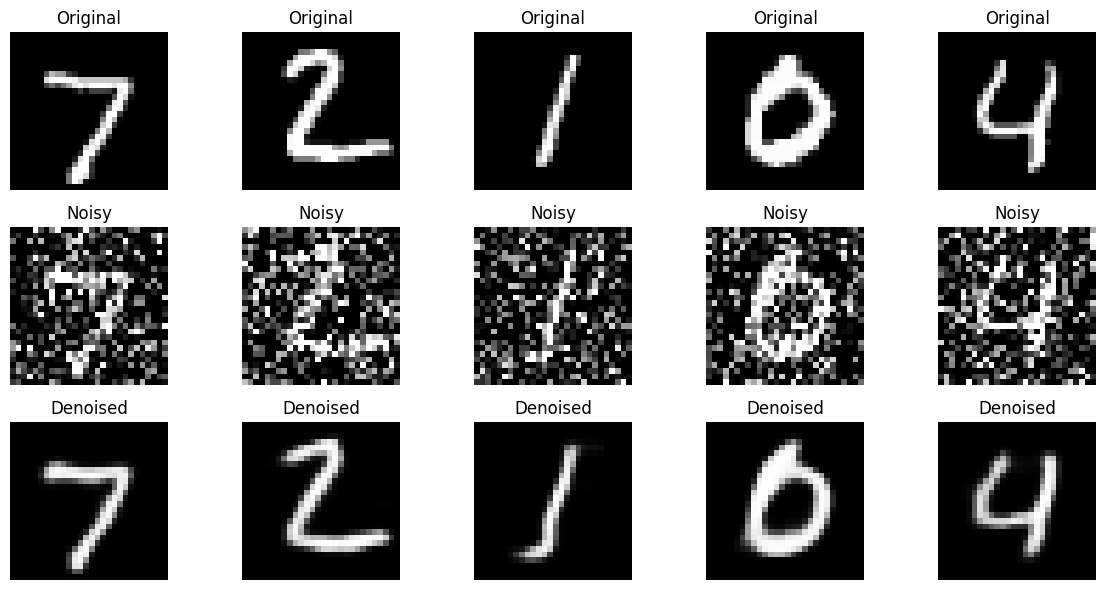

In [10]:
n = 5

plt.figure(figsize=(12,6))

for i in range(n):

    # Original
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Reconstruction Analysis

The autoencoder successfully learned to reconstruct clean digit images from heavily corrupted noisy inputs.

Visual inspection shows that most random noise was removed while preserving the overall digit structure. The reconstructed digits remain clearly recognizable even when the noisy inputs contain significant distortion.

Although some reconstructed images appear slightly blurred and lose fine-grained details, the model effectively captures the important visual features required for digit recognition.

These results demonstrate the ability of convolutional autoencoders to learn compressed representations that are useful for image denoising tasks.

## Experimental Result Validation

The denoising performance was evaluated using both reconstruction loss and qualitative image analysis.

Training loss and validation loss decreased consistently throughout training, indicating stable learning and good generalization.

The reconstructed outputs visually resemble the original clean images much more closely than the noisy inputs, confirming that the model successfully learned the denoising task.

This experiment highlights that reconstruction loss alone is not sufficient for evaluating image quality. Visual comparison between original, noisy, and denoised images is equally important for validating denoising performance.

## Limitations

- The model was evaluated primarily through visual inspection.
- Only Gaussian noise was considered during training.
- Some reconstructed digits exhibit slight blurring.
- MNIST is a relatively simple grayscale dataset and may not fully represent real-world image denoising challenges.
- More complex datasets may require deeper architectures and additional evaluation metrics.

## Conclusion

A convolutional autoencoder was successfully developed to remove noise from MNIST handwritten digit images.

The model learned compressed image representations and reconstructed cleaner versions of noisy inputs with low reconstruction loss.

Experimental results demonstrate that the autoencoder effectively removes noise while preserving important digit characteristics.

The project highlights the usefulness of autoencoders for image restoration tasks and demonstrates how deep learning can be applied to image denoising problems.